# 🌸 Iris Flower Classification

## Oasis Infobyte Internship Program

**Track:** Data Science

**Task 1:** Irirs-Flower-Classification

---


## 📌 Project Objective

The objective of this project is to build a Machine Learning classification model that can accurately identify the species of an Iris flower based on its physical measurements.

The model classifies flowers into the following three species:

- Iris Setosa
- Iris Versicolor
- Iris Virginica

---

## 📂 Dataset Information

| Property | Details |
|----------|----------|
| Dataset Name | Iris Dataset |
| Source | Scikit-Learn |
| Total Samples | 150 |
| Features | 4 |
| Classes | 3 |

### Input Features

- Sepal Length (cm)
- Sepal Width (cm)
- Petal Length (cm)
- Petal Width (cm)

### Target Variable

- Species

---

## 🤖 Machine Learning Algorithms Used

- Logistic Regression
- K-Nearest Neighbors (KNN)
- Decision Tree Classifier

---

## 📚 Python Libraries Used

- Pandas
- Matplotlib
- Seaborn
- Scikit-learn
- Joblib

---

## 🔄 Project Workflow

1. Import Required Libraries
2. Load Dataset
3. Exploratory Data Analysis (EDA)
4. Data Visualization
5. Feature Selection
6. Train-Test Split
7. Train Multiple Models
8. Evaluate Models
9. Compare Model Performance
10. Select Best Model
11. Make Sample Prediction
12. Save Trained Model
13. Calculate Execution Time

---

## 🎯 Expected Outcome

- Perform Exploratory Data Analysis
- Visualize the Iris Dataset
- Train multiple Machine Learning models
- Compare model performance
- Select the best-performing classifier
- Save the trained model for future use

---

In [1]:
# ==========================================================
# Iris Flower Classification
# Oasis Infobyte Internship - Task 1
# Step 1 : Import Required Libraries
# ==========================================================

# Standard Library
import os
import time

# Third-Party Libraries
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Scikit-Learn
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# ==========================================================
# Create Output Directory
# ==========================================================

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ==========================================================
# Start Execution Timer
# ==========================================================

start_time = time.time()

# ==========================================================
# Visualization Settings
# ==========================================================

sns.set_theme(
    style="whitegrid",
    palette="Set2",
    context="notebook"
)

plt.rcParams.update({

    "figure.figsize": (8, 5),
    "figure.dpi": 120,
    "savefig.dpi": 300,

    "axes.titlesize": 15,
    "axes.titleweight": "bold",

    "axes.labelsize": 12,
    "axes.labelweight": "bold",

    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    "legend.fontsize": 10,
    "grid.alpha": 0.4

})

print("=" * 60)
print("Libraries Imported Successfully")
print("=" * 60)
print(f"Output Folder : {OUTPUT_DIR}")

Libraries Imported Successfully
Output Folder : outputs


In [2]:
# ==========================================================
# Step 2 : Load Iris Dataset
# ==========================================================

# Load Iris dataset
iris = load_iris()

# Convert dataset into DataFrame
df = pd.DataFrame(
    data=iris.data,
    columns=iris.feature_names
)

# Add target labels
df["species"] = [
    iris.target_names[target]
    for target in iris.target
]

print("=" * 60)
print("IRIS DATASET LOADED SUCCESSFULLY")
print("=" * 60)

print(f"Dataset Shape : {df.shape}")
print(f"Total Features : {len(iris.feature_names)}")
print(f"Target Classes : {list(iris.target_names)}")

IRIS DATASET LOADED SUCCESSFULLY
Dataset Shape : (150, 5)
Total Features : 4
Target Classes : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


In [3]:
# ==========================================================
# Step 3 : Exploratory Data Analysis (EDA)
# ==========================================================

print("=" * 70)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 70)

# Dataset Shape
print("\n1. Dataset Shape")
print("-" * 30)
print(df.shape)

# First Five Rows
print("\n2. First Five Rows")
print("-" * 30)
display(df.head())

# Last Five Rows
print("\n3. Last Five Rows")
print("-" * 30)
display(df.tail())

# Dataset Information
print("\n4. Dataset Information")
print("-" * 30)
df.info()

# Missing Values
print("\n5. Missing Values")
print("-" * 30)

missing_values = df.isnull().sum()

display(
    pd.DataFrame({
        "Column": missing_values.index,
        "Missing Values": missing_values.values
    })
)

# Duplicate Records
print("\n6. Duplicate Records")
print("-" * 30)

duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

# Statistical Summary
print("\n7. Statistical Summary")
print("-" * 30)

display(df.describe().T)

# Data Types
print("\n8. Data Types")
print("-" * 30)

display(df.dtypes)

# Species Distribution
print("\n9. Species Distribution")
print("-" * 30)

species_count = df["species"].value_counts()

display(species_count)

print("\nPercentage Distribution")

display(
    round(
        df["species"].value_counts(normalize=True) * 100,
        2
    )
)

print("\nEDA Completed Successfully.")

EXPLORATORY DATA ANALYSIS (EDA)

1. Dataset Shape
------------------------------
(150, 5)

2. First Five Rows
------------------------------


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



3. Last Five Rows
------------------------------


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica



4. Dataset Information
------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB

5. Missing Values
------------------------------


...


9. Species Distribution
------------------------------


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


Percentage Distribution


species
setosa        33.33
versicolor    33.33
virginica     33.33
Name: proportion, dtype: float64


EDA Completed Successfully.


FEATURE DISTRIBUTION


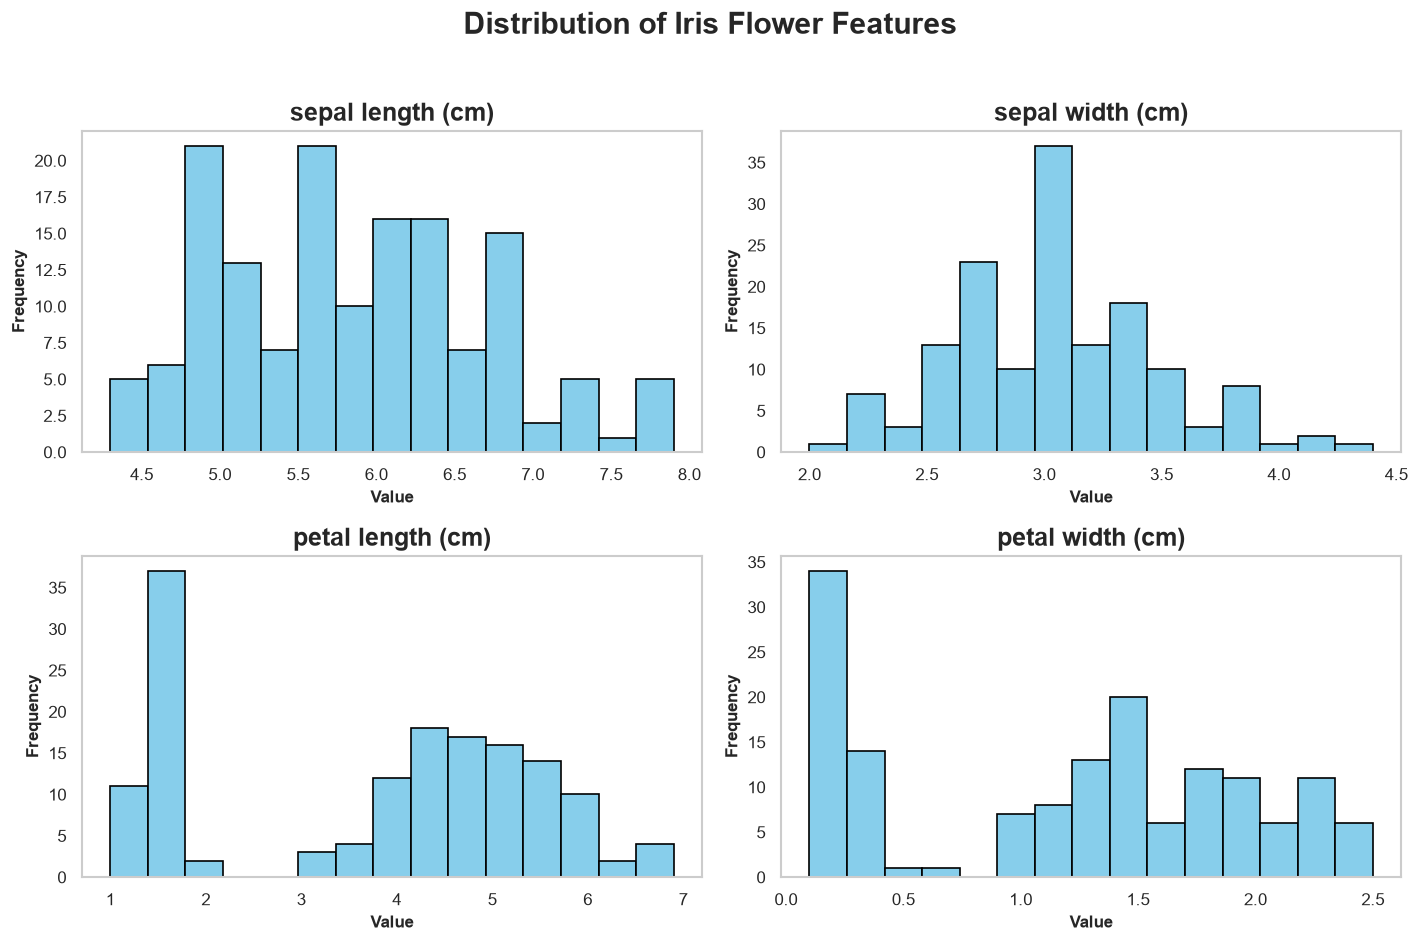

Histogram saved successfully.


In [4]:
# ==========================================================
# Step 4 : Feature Distribution using Histograms
# ==========================================================

print("=" * 70)
print("FEATURE DISTRIBUTION")
print("=" * 70)

# Numerical Features
features = iris.feature_names

# Create Histograms
fig = df[features].hist(
    figsize=(12, 8),
    bins=15,
    edgecolor="black",
    color="skyblue",
    grid=False
)

# Improve each subplot
for ax in fig.flatten():

    ax.set_xlabel("Value", fontsize=10)
    ax.set_ylabel("Frequency", fontsize=10)

# Main Title
plt.suptitle(
    "Distribution of Iris Flower Features",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

# Save Figure
plt.savefig(
    f"{OUTPUT_DIR}/histograms.png",
    dpi=300,
    bbox_inches="tight"
)

# Display
plt.show()

# Free Memory
plt.close()

print("Histogram saved successfully.")

PAIRPLOT VISUALIZATION


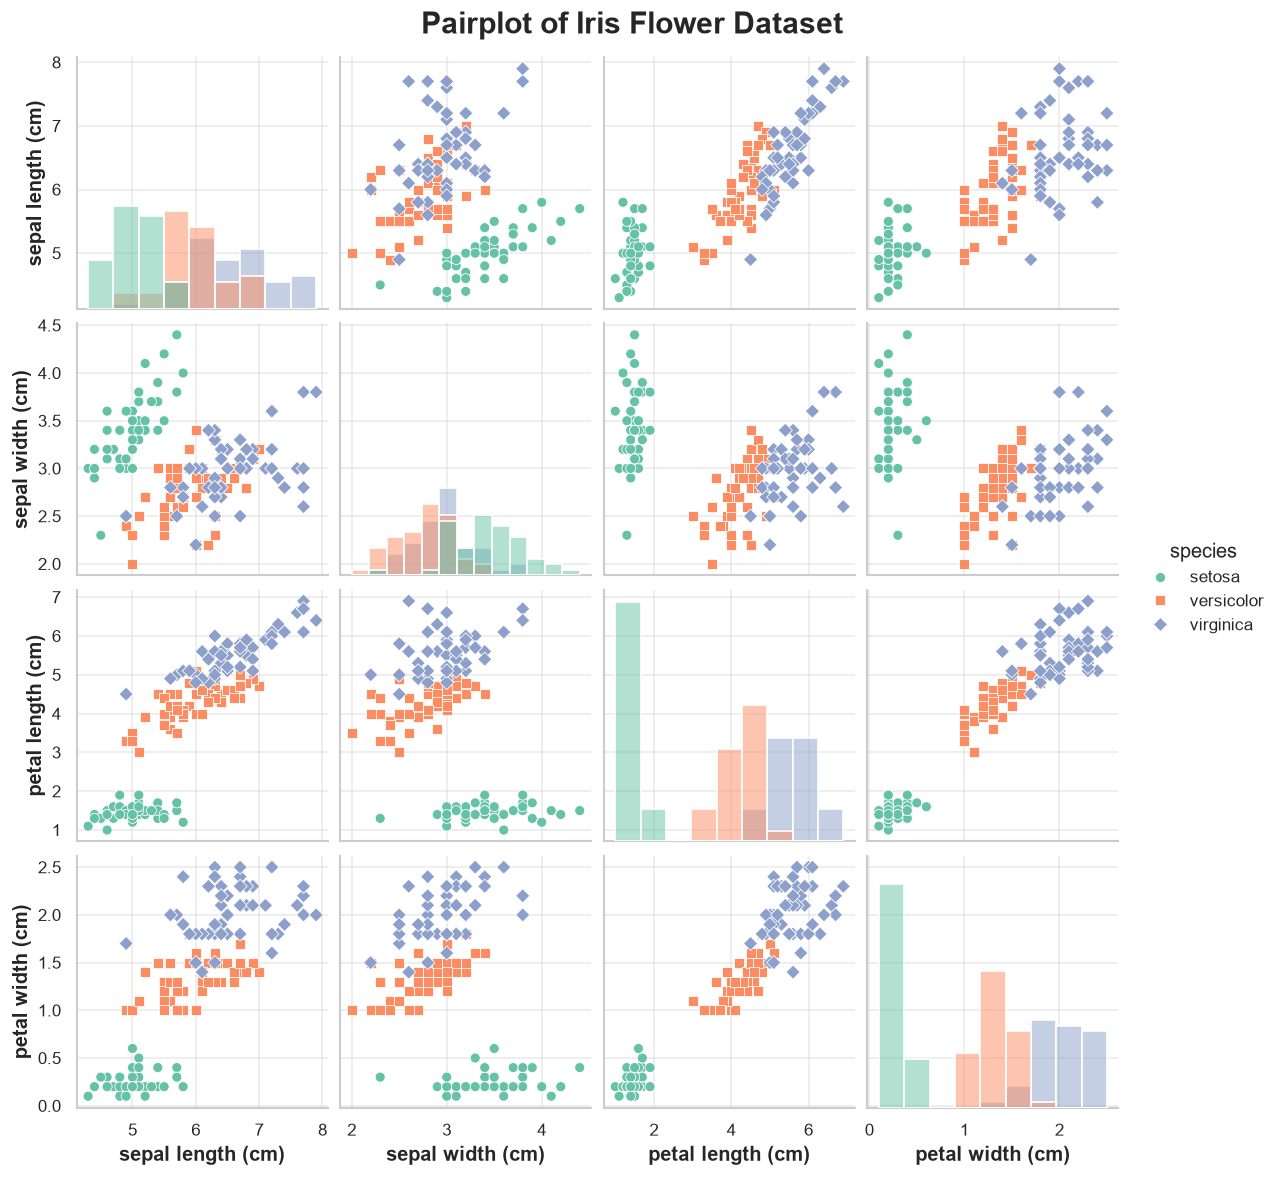

Pairplot saved successfully.


In [5]:
# ==========================================================
# Step 5 : Pairplot Visualization
# ==========================================================

print("=" * 70)
print("PAIRPLOT VISUALIZATION")
print("=" * 70)

# Create Pairplot
pairplot = sns.pairplot(
    data=df,
    hue="species",
    palette="Set2",
    markers=["o", "s", "D"],
    diag_kind="hist",
    corner=False,
    height=2.4
)

# Main Title
pairplot.fig.suptitle(
    "Pairplot of Iris Flower Dataset",
    fontsize=18,
    fontweight="bold",
    y=1.02
)

# Save Figure
pairplot.savefig(
    f"{OUTPUT_DIR}/pairplot.png",
    dpi=300,
    bbox_inches="tight"
)

# Display Figure
plt.show()

# Close Figure
plt.close()

print("Pairplot saved successfully.")

CORRELATION HEATMAP


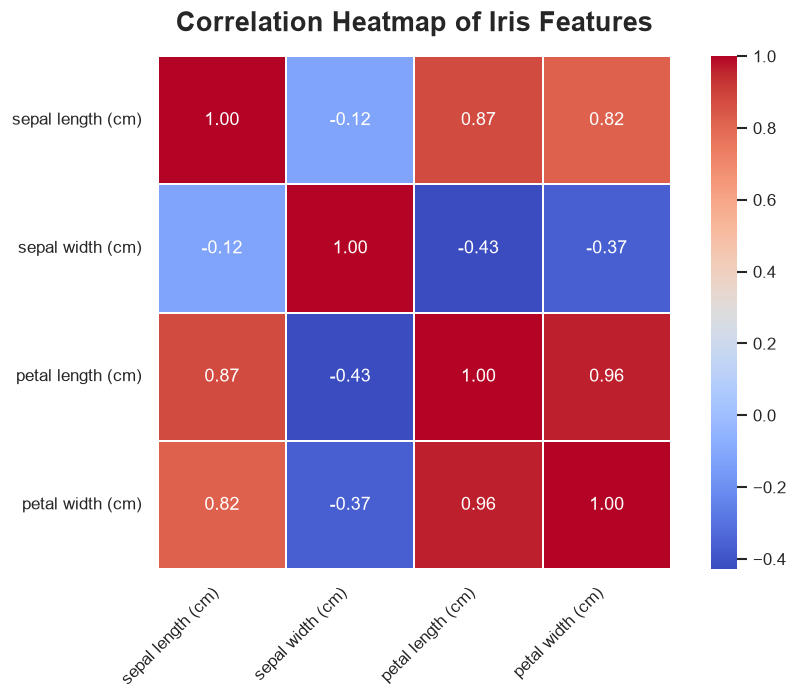

Heatmap saved successfully.

Correlation Matrix


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.00,-0.12,0.87,0.82
sepal width (cm),-0.12,1.00,-0.43,-0.37
petal length (cm),0.87,-0.43,1.00,0.96
petal width (cm),0.82,-0.37,0.96,1.00


In [6]:
# ==========================================================
# Step 6 : Correlation Heatmap
# ==========================================================

print("=" * 70)
print("CORRELATION HEATMAP")
print("=" * 70)

# Calculate Correlation Matrix
correlation_matrix = df[features].corr()

# Create Figure
plt.figure(figsize=(8, 6))

# Draw Heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=1,
    square=True,
    cbar=True,
    annot_kws={"size": 11}
)

# Title
plt.title(
    "Correlation Heatmap of Iris Features",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

# Save Figure
plt.savefig(
    f"{OUTPUT_DIR}/heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

# Display Figure
plt.show()

# Close Figure
plt.close()

print("Heatmap saved successfully.")

# Display Correlation Values
print("\nCorrelation Matrix")
display(correlation_matrix.round(2))

BOXPLOT VISUALIZATION


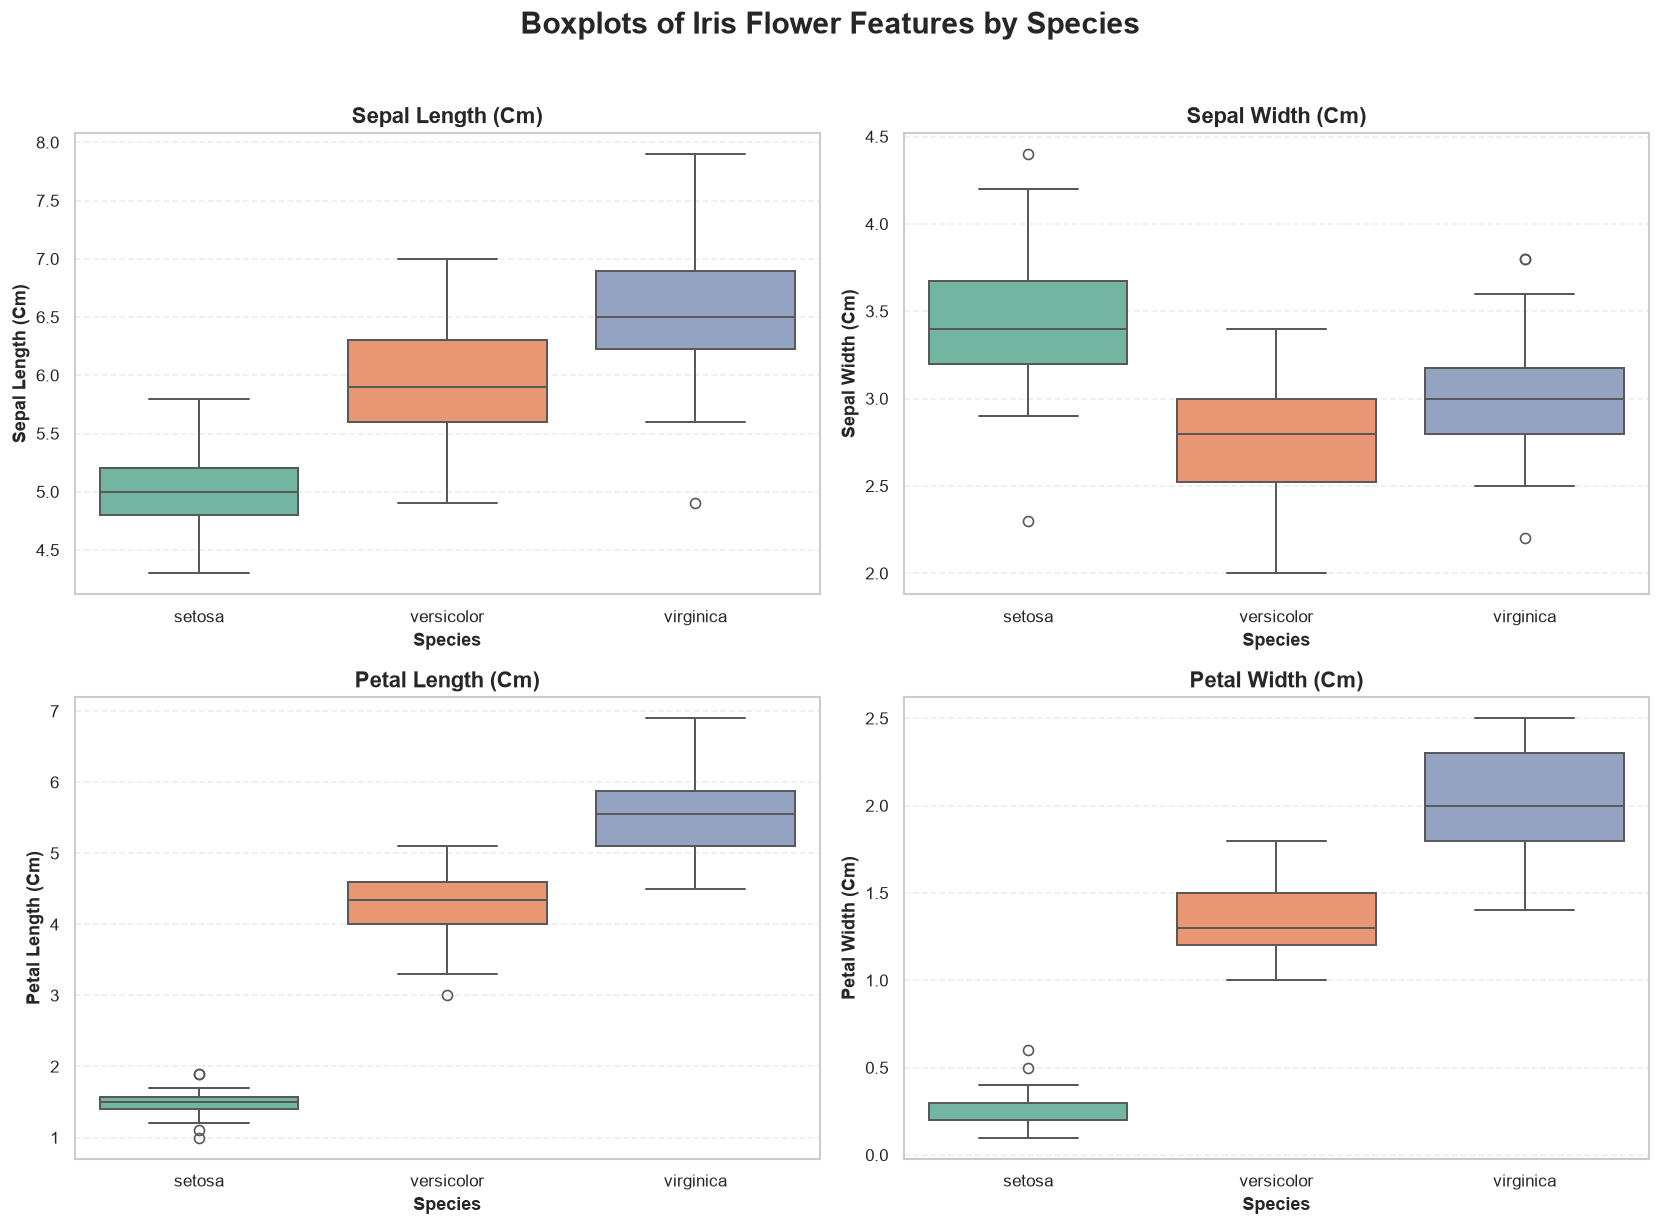

Boxplots saved successfully.


In [7]:
# ==========================================================
# Step 7 : Boxplot Visualization
# ==========================================================

print("=" * 70)
print("BOXPLOT VISUALIZATION")
print("=" * 70)

# Create Figure
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 10)
)

# Flatten axes for easy iteration
axes = axes.flatten()

# Plot Boxplots
for ax, feature in zip(axes, features):

    sns.boxplot(
        data=df,
        x="species",
        y=feature,
        hue="species",
        palette="Set2",
        legend=False,
        linewidth=1.2,
        ax=ax
    )

    ax.set_title(
        f"{feature.title()}",
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Species",
        fontsize=11,
        fontweight="bold"
    )

    ax.set_ylabel(
        feature.title(),
        fontsize=11,
        fontweight="bold"
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.35
    )

# Main Title
fig.suptitle(
    "Boxplots of Iris Flower Features by Species",
    fontsize=18,
    fontweight="bold",
    y=1.02
)

# Adjust Layout
plt.tight_layout()

# Save Figure
plt.savefig(
    f"{OUTPUT_DIR}/boxplots.png",
    dpi=300,
    bbox_inches="tight"
)

# Display Figure
plt.show()

# Free Memory
plt.close()

print("Boxplots saved successfully.")

In [8]:
# ==========================================================
# Step 8 : Feature Selection Analysis
# ==========================================================

print("=" * 70)
print("FEATURE SELECTION ANALYSIS")
print("=" * 70)

# Correlation of Features
correlation = df[features].corr()

display(correlation.round(2))

print("\nFeature Selection Summary")
print("-" * 70)

print("""
1. Petal Length
   • Strongly separates the three Iris species.
   • One of the most important features for classification.

2. Petal Width
   • Highly correlated with Petal Length.
   • Plays a major role in identifying species.

3. Sepal Length
   • Provides moderate discrimination.
   • Useful when combined with petal features.

4. Sepal Width
   • Least informative feature.
   • Still contributes useful information during model training.
""")

print("-" * 70)
print("Selected Features for Model Training")

selected_features = features

for index, feature in enumerate(selected_features, start=1):
    print(f"{index}. {feature}")

print("-" * 70)
print("Conclusion")
print(
    "Petal Length and Petal Width are the most discriminative "
    "features for classifying Iris flowers."
)

FEATURE SELECTION ANALYSIS


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.00,-0.12,0.87,0.82
sepal width (cm),-0.12,1.00,-0.43,-0.37
petal length (cm),0.87,-0.43,1.00,0.96
petal width (cm),0.82,-0.37,0.96,1.00



Feature Selection Summary
----------------------------------------------------------------------

1. Petal Length
   • Strongly separates the three Iris species.
   • One of the most important features for classification.

2. Petal Width
   • Highly correlated with Petal Length.
   • Plays a major role in identifying species.

3. Sepal Length
   • Provides moderate discrimination.
   • Useful when combined with petal features.

4. Sepal Width
   • Least informative feature.
   • Still contributes useful information during model training.

----------------------------------------------------------------------
Selected Features for Model Training
1. sepal length (cm)
2. sepal width (cm)
3. petal length (cm)
4. petal width (cm)
----------------------------------------------------------------------
Conclusion
Petal Length and Petal Width are the most discriminative features for classifying Iris flowers.


In [9]:
# ==========================================================
# Step 9 : Train-Test Split
# ==========================================================

print("=" * 70)
print("TRAIN - TEST SPLIT")
print("=" * 70)

# Input Features
X = df[features]

# Target Variable
y = df["species"]

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display Dataset Information
print(f"Total Samples      : {len(df)}")
print(f"Training Samples   : {len(X_train)}")
print(f"Testing Samples    : {len(X_test)}")

print(f"\nTraining Percentage : {(len(X_train)/len(df))*100:.0f}%")
print(f"Testing Percentage  : {(len(X_test)/len(df))*100:.0f}%")

print("\nFeature Matrix Shape")
print("-" * 30)
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

print("\nTarget Vector Shape")
print("-" * 30)
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

print("\nClass Distribution in Training Set")
print("-" * 30)
print(y_train.value_counts())

print("\nClass Distribution in Testing Set")
print("-" * 30)
print(y_test.value_counts())

print("\nTrain-Test Split Completed Successfully.")

TRAIN - TEST SPLIT
Total Samples      : 150
Training Samples   : 120
Testing Samples    : 30

Training Percentage : 80%
Testing Percentage  : 20%

Feature Matrix Shape
------------------------------
X_train : (120, 4)
X_test  : (30, 4)

Target Vector Shape
------------------------------
y_train : (120,)
y_test  : (30,)

Class Distribution in Training Set
------------------------------
species
setosa        40
virginica     40
versicolor    40
Name: count, dtype: int64

Class Distribution in Testing Set
------------------------------
species
setosa        10
virginica     10
versicolor    10
Name: count, dtype: int64

Train-Test Split Completed Successfully.


MODEL TRAINING AND EVALUATION

Training Model : Logistic Regression

Accuracy : 96.67%

Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        10
  versicolor     1.0000    0.9000    0.9474        10
   virginica     0.9091    1.0000    0.9524        10

    accuracy                         0.9667        30
   macro avg     0.9697    0.9667    0.9666        30
weighted avg     0.9697    0.9667    0.9666        30



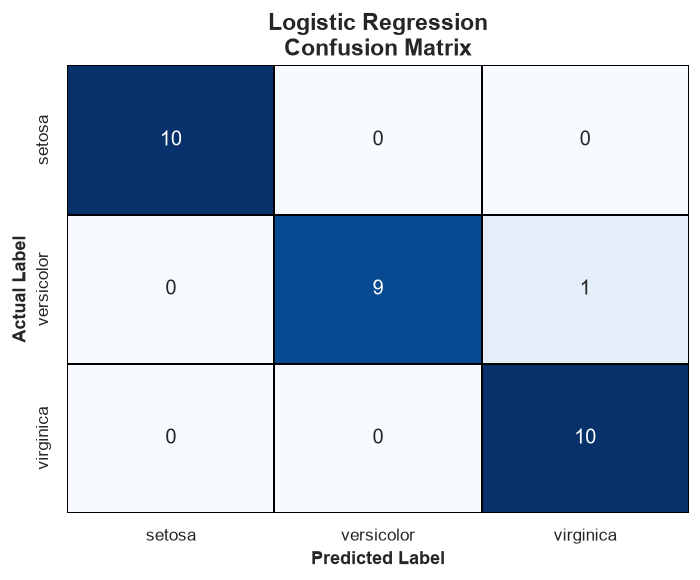

Confusion Matrix Saved : confusion_matrix_logistic_regression.png

Training Model : K-Nearest Neighbors

Accuracy : 100.00%

Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        10
  versicolor     1.0000    1.0000    1.0000        10
   virginica     1.0000    1.0000    1.0000        10

    accuracy                         1.0000        30
   macro avg     1.0000    1.0000    1.0000        30
weighted avg     1.0000    1.0000    1.0000        30



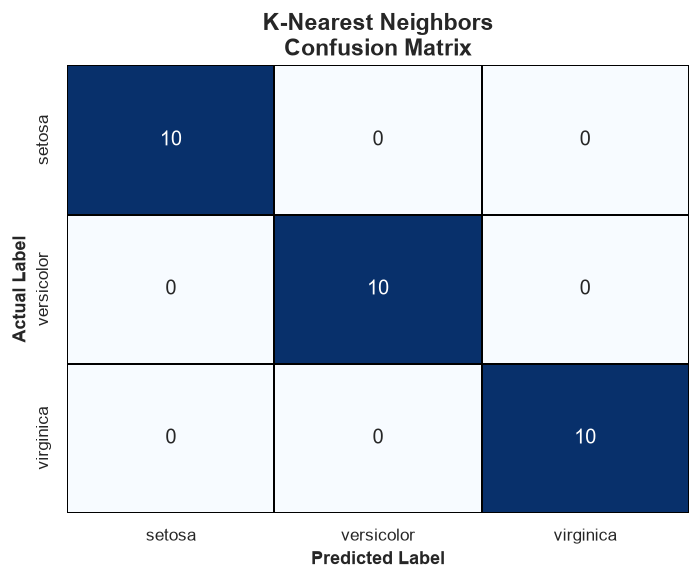

Confusion Matrix Saved : confusion_matrix_knearest_neighbors.png

Training Model : Decision Tree

Accuracy : 93.33%

Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        10
  versicolor     0.9000    0.9000    0.9000        10
   virginica     0.9000    0.9000    0.9000        10

    accuracy                         0.9333        30
   macro avg     0.9333    0.9333    0.9333        30
weighted avg     0.9333    0.9333    0.9333        30



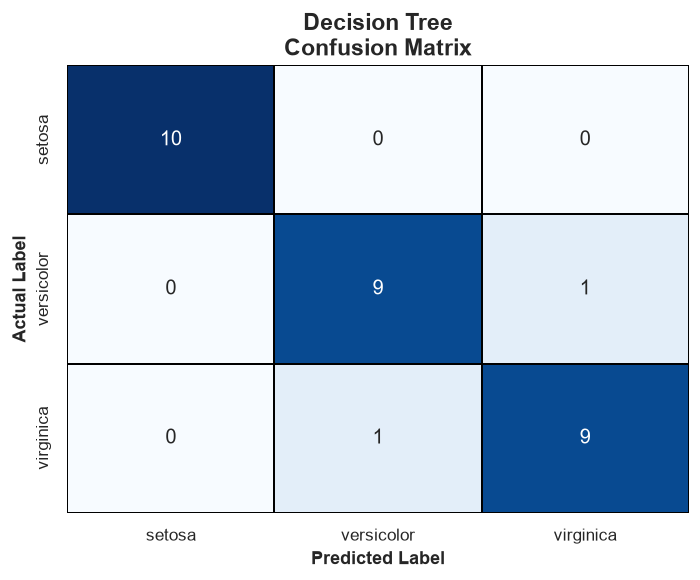

Confusion Matrix Saved : confusion_matrix_decision_tree.png

ALL MODELS TRAINED SUCCESSFULLY


In [10]:
# ==========================================================
# Step 10 : Model Training and Evaluation
# ==========================================================

print("=" * 70)
print("MODEL TRAINING AND EVALUATION")
print("=" * 70)

# Machine Learning Models
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=300,
        random_state=42
    ),

    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    )

}

# Store Accuracy Scores
results = {}

# Train Each Model
for name, model in models.items():

    print("\n" + "=" * 70)
    print(f"Training Model : {name}")
    print("=" * 70)

    # Train Model
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    results[name] = accuracy

    print(f"\nAccuracy : {accuracy * 100:.2f}%")

    # Classification Report
    print("\nClassification Report")
    print("-" * 50)

    print(
        classification_report(
            y_test,
            y_pred,
            digits=4
        )
    )

    # Confusion Matrix
    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=iris.target_names
    )

    # Plot
    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        linewidths=1,
        linecolor="black",
        cbar=False,
        xticklabels=iris.target_names,
        yticklabels=iris.target_names
    )

    plt.title(
        f"{name}\nConfusion Matrix",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel(
        "Predicted Label",
        fontsize=11,
        fontweight="bold"
    )

    plt.ylabel(
        "Actual Label",
        fontsize=11,
        fontweight="bold"
    )

    plt.tight_layout()

    # Safe filename
    filename = (
        name.lower()
        .replace(" ", "_")
        .replace("-", "")
    )

    plt.savefig(
        f"{OUTPUT_DIR}/confusion_matrix_{filename}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

    print(
        f"Confusion Matrix Saved : confusion_matrix_{filename}.png"
    )

print("\n" + "=" * 70)
print("ALL MODELS TRAINED SUCCESSFULLY")
print("=" * 70)

MODEL COMPARISON


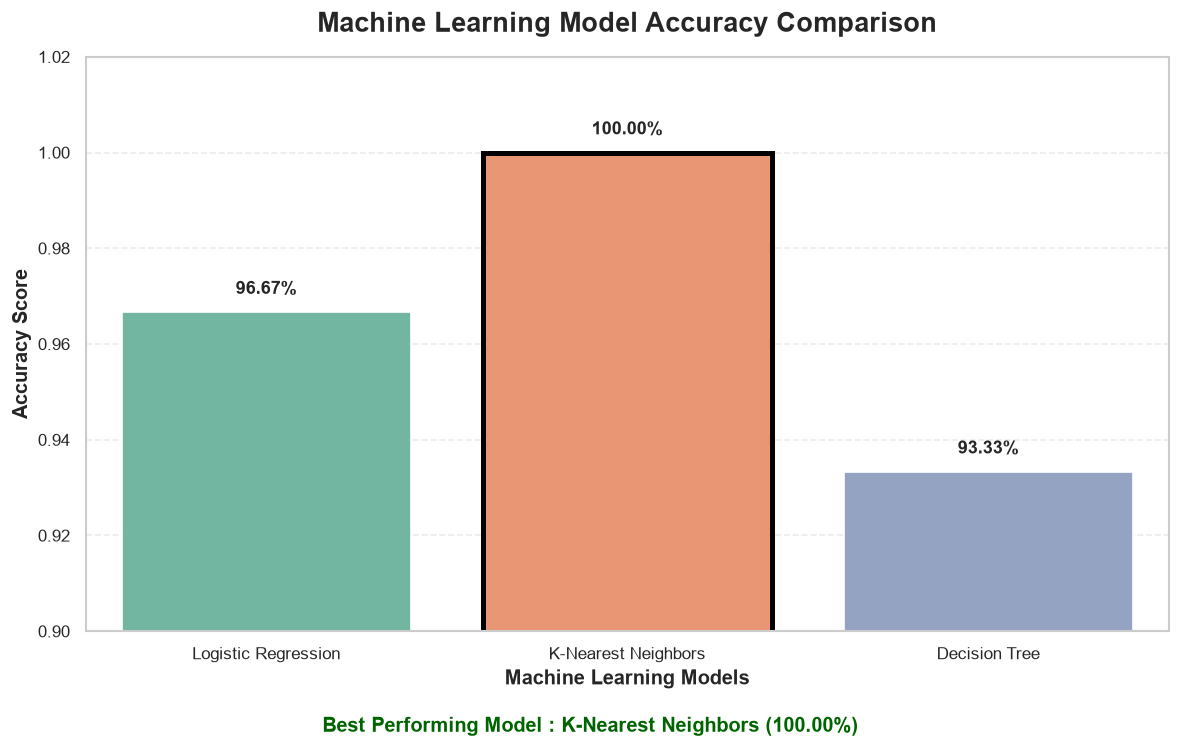


Model Comparison Graph Saved Successfully.

Best Model : K-Nearest Neighbors
Accuracy   : 100.00%


In [11]:
# ==========================================================
# Step 11 : Model Comparison
# ==========================================================

print("=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

# Best Model
best_model_name = max(results, key=results.get)
best_accuracy = results[best_model_name]

# Create Figure
plt.figure(figsize=(10, 6))

# Create Bar Plot
ax = sns.barplot(
    x=list(results.keys()),
    y=list(results.values()),
    hue=list(results.keys()),
    palette="Set2",
    legend=False
)

# Highlight Best Model
for bar, model_name in zip(ax.patches, results.keys()):

    if model_name == best_model_name:
        bar.set_edgecolor("black")
        bar.set_linewidth(3)

# Add Accuracy Labels
for bar in ax.patches:

    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.003,
        f"{height * 100:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# Labels
plt.xlabel(
    "Machine Learning Models",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Accuracy Score",
    fontsize=12,
    fontweight="bold"
)

plt.title(
    "Machine Learning Model Accuracy Comparison",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# Grid
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

# Accuracy Range
plt.ylim(0.90, 1.02)

# Show Best Model
plt.figtext(
    0.5,
    -0.03,
    f"Best Performing Model : {best_model_name} ({best_accuracy * 100:.2f}%)",
    ha="center",
    fontsize=12,
    fontweight="bold",
    color="darkgreen"
)

plt.tight_layout()

# Save Figure
plt.savefig(
    f"{OUTPUT_DIR}/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

print("\nModel Comparison Graph Saved Successfully.")

print(f"\nBest Model : {best_model_name}")
print(f"Accuracy   : {best_accuracy * 100:.2f}%")

BEST MODEL SELECTION
Best Model : K-Nearest Neighbors
Accuracy   : 100.00%

FEATURE IMPORTANCE


,Feature,Importance
0,petal length (cm),0.558568
1,petal width (cm),0.406015
2,sepal width (cm),0.029167
3,sepal length (cm),0.006250


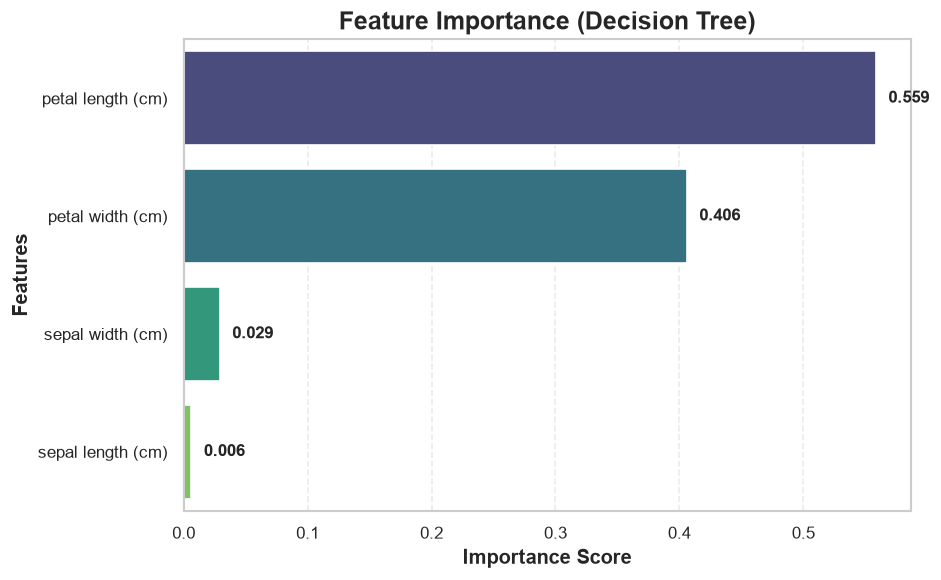


Feature Importance Graph Saved Successfully.


In [12]:
# ==========================================================
# Step 12 : Best Model Selection & Feature Importance
# ==========================================================

print("=" * 70)
print("BEST MODEL SELECTION")
print("=" * 70)

# Select Best Model
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
best_accuracy = results[best_model_name]

print(f"Best Model : {best_model_name}")
print(f"Accuracy   : {best_accuracy * 100:.2f}%")

# ==========================================================
# Feature Importance (Decision Tree)
# ==========================================================

print("\n" + "=" * 70)
print("FEATURE IMPORTANCE")
print("=" * 70)

# Decision Tree Feature Importance
feature_importance = pd.DataFrame({

    "Feature": features,
    "Importance": models["Decision Tree"].feature_importances_

})

# Sort Values
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# Display Table
display(feature_importance)

# ==========================================================
# Plot Feature Importance
# ==========================================================

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

# Add Importance Values
for bar in ax.patches:

    width = bar.get_width()

    ax.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Feature Importance (Decision Tree)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Importance Score",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Features",
    fontsize=12,
    fontweight="bold"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

# Save Figure
plt.savefig(
    f"{OUTPUT_DIR}/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("\nFeature Importance Graph Saved Successfully.")

In [13]:
# ==========================================================
# Step 13 : Sample Prediction
# ==========================================================

print("=" * 70)
print("SAMPLE PREDICTION")
print("=" * 70)

# Select a Sample from Test Data
sample = X_test.iloc[[0]]

# Actual Class
actual_species = y_test.iloc[0]

# Predict Species
predicted_species = best_model.predict(sample)[0]

print("\nInput Features")
print("-" * 70)

display(sample)

print("\nPrediction Result")
print("-" * 70)

print(f"Predicted Species : {predicted_species}")
print(f"Actual Species    : {actual_species}")

# Prediction Status
if predicted_species == actual_species:
    print("\nPrediction Status : Correct")
else:
    print("\nPrediction Status : Incorrect")

print("-" * 70)

# Prediction Probability (if supported)
if hasattr(best_model, "predict_proba"):

    probabilities = best_model.predict_proba(sample)[0]

    probability_df = pd.DataFrame({
        "Species": best_model.classes_,
        "Probability": probabilities
    })

    probability_df["Probability"] = (
        probability_df["Probability"] * 100
    ).round(2)

    print("\nPrediction Confidence")
    print("-" * 70)

    display(
        probability_df.sort_values(
            by="Probability",
            ascending=False
        ).reset_index(drop=True)
    )

print("\nSample Prediction Completed Successfully.")

SAMPLE PREDICTION

Input Features
----------------------------------------------------------------------


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
38,4.4,3.0,1.3,0.2



Prediction Result
----------------------------------------------------------------------
Predicted Species : setosa
Actual Species    : setosa

Prediction Status : Correct
----------------------------------------------------------------------

Prediction Confidence
----------------------------------------------------------------------


,Species,Probability
0,setosa,100.0
1,versicolor,0.0
2,virginica,0.0



Sample Prediction Completed Successfully.


In [14]:
# ==========================================================
# Step 14 : Save Best Model
# ==========================================================

print("=" * 70)
print("SAVE BEST MODEL")
print("=" * 70)

model_path = "iris_best_model.pkl"

# Save Model
joblib.dump(best_model, model_path)

# Verify
if os.path.exists(model_path):

    file_size = os.path.getsize(model_path) / 1024

    print("\nModel Saved Successfully.")
    print(f"Best Model : {best_model_name}")
    print(f"Accuracy   : {best_accuracy * 100:.2f}%")
    print(f"File Name  : {model_path}")
    print(f"File Size  : {file_size:.2f} KB")

else:

    print("Error: Model could not be saved.")

print("\nModel Serialization Completed Successfully.")

SAVE BEST MODEL

Model Saved Successfully.
Best Model : K-Nearest Neighbors
Accuracy   : 100.00%
File Name  : iris_best_model.pkl
File Size  : 11.69 KB

Model Serialization Completed Successfully.


In [15]:
# ==========================================================
# Step 15 : Execution Time & Project Summary
# ==========================================================

# Stop Execution Timer
end_time = time.time()
execution_time = end_time - start_time

print("=" * 70)
print("IRIS FLOWER CLASSIFICATION PROJECT SUMMARY")
print("=" * 70)

# ==========================================================
# Dataset Information
# ==========================================================

print("\nDataset Information")
print("-" * 70)

print(f"Dataset Name           : Iris Flower Dataset")
print(f"Total Samples          : {len(df)}")
print(f"Number of Features     : {len(features)}")
print(f"Number of Classes      : {df['species'].nunique()}")

# ==========================================================
# Model Performance
# ==========================================================

print("\nMachine Learning Models Performance")
print("-" * 70)

for model_name, accuracy in results.items():
    print(f"{model_name:<25} : {accuracy * 100:.2f}%")

# ==========================================================
# Best Model
# ==========================================================

print("\nBest Performing Model")
print("-" * 70)

print(f"Model Name             : {best_model_name}")
print(f"Accuracy Score         : {best_accuracy * 100:.2f}%")

# ==========================================================
# Generated Output Files
# ==========================================================

print("\nGenerated Output Files")
print("-" * 70)

output_files = sorted([
    file for file in os.listdir(OUTPUT_DIR)
    if file.endswith(".png")
])

print(f"Images Generated : {len(output_files)}")
print("Output Folder    : outputs/")
print("Model File       : iris_best_model.pkl")

# ==========================================================
# Saved Model
# ==========================================================

print("\nSaved Model")
print("-" * 70)

if os.path.exists("iris_best_model.pkl"):

    size = os.path.getsize("iris_best_model.pkl") / 1024

    print("Model File             : iris_best_model.pkl")
    print(f"Model Size             : {size:.2f} KB")

else:

    print("Model File             : Not Found")

# ==========================================================
# Execution Details
# ==========================================================

print("\nExecution Details")
print("-" * 70)

print(f"Total Execution Time   : {execution_time:.2f} seconds")

# ==========================================================
# Project Status
# ==========================================================

print("\nProject Status")
print("-" * 70)

print("Project Completed Successfully.")
print("All visualizations generated successfully.")
print("Best model trained and saved successfully.")
print("Project is ready for GitHub and Oasis Infobyte submission.")

print("=" * 70)
print("THANK YOU")
print("=" * 70)

IRIS FLOWER CLASSIFICATION PROJECT SUMMARY

Dataset Information
----------------------------------------------------------------------
Dataset Name           : Iris Flower Dataset
Total Samples          : 150
Number of Features     : 4
Number of Classes      : 3

Machine Learning Models Performance
----------------------------------------------------------------------
Logistic Regression       : 96.67%
K-Nearest Neighbors       : 100.00%
Decision Tree             : 93.33%

Best Performing Model
----------------------------------------------------------------------
Model Name             : K-Nearest Neighbors
Accuracy Score         : 100.00%

Generated Output Files
----------------------------------------------------------------------
Images Generated : 9
Output Folder    : outputs/
Model File       : iris_best_model.pkl

Saved Model
----------------------------------------------------------------------
Model File             : iris_best_model.pkl
Model Size             : 11.69 KB

Exec